AIM: To implement an Artificial Neural Network (ANN) model to predict stock prices.


ALGORITHMS:
1. Load stock price dataset
2. Select required feature (closing price)
3. Normalize data (scale between 0 and 1)
4. Prepare training and testing data
5. Build ANN model
6. Train model
7. Predict stock prices
8. Compare actual vs predicted values

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


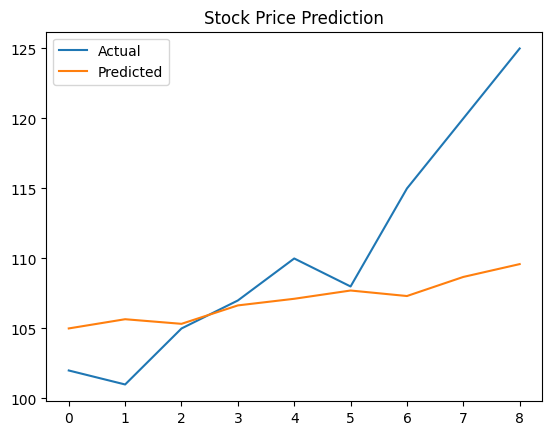

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create sample stock data
data = {
    'price': [100, 102, 101, 105, 107, 110, 108, 115, 120, 125]
}
df = pd.DataFrame(data)

# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Prepare dataset
X = []
y = []

for i in range(len(scaled_data)-1):
    X.append(scaled_data[i])
    y.append(scaled_data[i+1])

X = np.array(X)
y = np.array(y)

# Build ANN model
model = Sequential()
model.add(Dense(10, activation='relu', input_dim=1))
model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(X, y, epochs=100, verbose=0)

# Predict
predicted = model.predict(X)

# Convert back to original values
predicted_prices = scaler.inverse_transform(predicted)

# Plot
plt.plot(df['price'].values[1:], label="Actual")
plt.plot(predicted_prices, label="Predicted")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()